In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
def get_patches(ld, nd, patch_size=64, n_patches=4):
    h, w = ld.shape
    ld_patches, nd_patches = [], []
    for _ in range(n_patches):
        i = np.random.randint(0, h - patch_size)
        j = np.random.randint(0, w - patch_size)
        ld_patches.append(ld[i:i+patch_size, j:j+patch_size])
        nd_patches.append(nd[i:i+patch_size, j:j+patch_size])
    return np.array(ld_patches), np.array(nd_patches)


class CTDataset(Dataset):
    def __init__(self, ldct_list, ndct_list, train=True):
        self.ldct_list = ldct_list
        self.ndct_list = ndct_list
        self.train     = train

    def __len__(self):
        return len(self.ldct_list)

    def __getitem__(self, idx):
        ld_img = Image.open(self.ldct_list[idx]).convert('L')
        nd_img = Image.open(self.ndct_list[idx]).convert('L')
        ld = np.array(ld_img).astype(np.float32) / 255.0
        nd = np.array(nd_img).astype(np.float32) / 255.0
        ld = np.clip(ld, 0, 1)
        nd = np.clip(nd, 0, 1)
        if self.train:
            ld_patches, nd_patches = get_patches(ld, nd)
            ld_patches = torch.from_numpy(ld_patches).unsqueeze(1)
            nd_patches = torch.from_numpy(nd_patches).unsqueeze(1)
            return ld_patches, nd_patches
        return (torch.from_numpy(ld).unsqueeze(0),
                torch.from_numpy(nd).unsqueeze(0))


def collect_image_paths(root_dir,
                        slice_thickness="1mm",
                        kernel="Soft Kernel (B30)"):
    ld_root = os.path.join(root_dir, "Quarter Dose",
                           slice_thickness, kernel)
    nd_root = os.path.join(root_dir, "Full Dose",
                           slice_thickness, kernel)
    ld_files, nd_files = [], []
    for patient in sorted(os.listdir(ld_root)):
        ld_p = os.path.join(ld_root, patient)
        nd_p = os.path.join(nd_root, patient)
        for ld_s, nd_s in zip(sorted(os.listdir(ld_p)),
                               sorted(os.listdir(nd_p))):
            ld_files.append(os.path.join(ld_p, ld_s))
            nd_files.append(os.path.join(nd_p, nd_s))
    return ld_files, nd_files


# Load data
data_root = "/kaggle/input/datasets/andrewmvd/ct-low-dose-reconstruction/Preprocessed_512x512/512"
ldct_files, ndct_files = collect_image_paths(data_root)
print(f"Total pairs: {len(ldct_files)}")

# Split
split    = int(0.9 * len(ldct_files))
train_ld = ldct_files[:split]
train_nd = ndct_files[:split]
test_ld  = ldct_files[split:]
test_nd  = ndct_files[split:]

# ── Use only 50% of training data to save time ──
train_ld = train_ld[:len(train_ld)//2]
train_nd = train_nd[:len(train_nd)//2]
print(f"Using {len(train_ld)} training images (50% of full data)")

# Datasets
train_dataset = CTDataset(train_ld, train_nd, train=True)
test_dataset  = CTDataset(test_ld,  test_nd,  train=False)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8,
                          shuffle=True,  num_workers=2,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=1,
                          shuffle=False, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Test  batches : {len(test_loader)}")

Total pairs: 5936
Using 2671 training images (50% of full data)
Train batches : 334
Test  batches : 594


In [3]:
#Generator 
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        # Encoder
        self.enc1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.enc4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )

        # Decoder — input channels = current + skip connection
        self.dec4 = nn.Sequential(
            nn.Conv2d(256 + 256, 128, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.dec3 = nn.Sequential(
            nn.Conv2d(128 + 128, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.dec2 = nn.Sequential(
            nn.Conv2d(64 + 64, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(32 + 32, 1, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        # Encode
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)
        # Bottleneck
        b  = self.bottleneck(e4)
        # Decode with skip connections
        d4 = self.dec4(torch.cat([b,  e4], dim=1))
        d3 = self.dec3(torch.cat([d4, e3], dim=1))
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        d1 = self.dec1(torch.cat([d2, e1], dim=1))
        # Global residual
        return torch.clamp(x + d1, 0, 1)


# Test
g = Generator().to(DEVICE)
dummy = torch.randn(2, 1, 64, 64).to(DEVICE)
print("Generator output shape:", g(dummy).shape)
print(f"Generator parameters : {sum(p.numel() for p in g.parameters()):,}")

Generator output shape: torch.Size([2, 1, 64, 64])
Generator parameters : 1,752,865


In [5]:
#Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # Layer 1
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            # Layer 2
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # Layer 3
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # Layer 4
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # Output
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),
        )

    def forward(self, ldct, clean):
        x = torch.cat([ldct, clean], dim=1)
        return self.model(x)


# Test
d = Discriminator().to(DEVICE)
fake = torch.randn(2, 1, 64, 64).to(DEVICE)
print("Discriminator output shape:", d(dummy, fake).shape)
print(f"Discriminator parameters : {sum(p.numel() for p in d.parameters()):,}")

Discriminator output shape: torch.Size([2, 1, 1, 1])
Discriminator parameters : 2,765,505


In [6]:
#Training function
def compute_gradient_penalty(discriminator, ldct, real, fake, device):
    alpha        = torch.rand(real.size(0), 1, 1, 1, device=device)
    interpolated = (alpha * real + (1 - alpha) * fake).requires_grad_(True)
    d_interp     = discriminator(ldct, interpolated)
    gradients    = torch.autograd.grad(
        outputs=d_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True,
        retain_graph=True
    )[0]
    gradients = gradients.view(gradients.size(0), -1)
    penalty   = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return penalty


def train_gan(generator, discriminator, train_loader, test_loader,
              epochs=50, lr_g=1e-4, lr_d=1e-4,
              lambda_gp=10, lambda_pixel=100, n_critic=5):

    generator     = generator.to(DEVICE)
    discriminator = discriminator.to(DEVICE)

    opt_g = torch.optim.Adam(generator.parameters(),
                              lr=lr_g, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(),
                              lr=lr_d, betas=(0.5, 0.999))

    pixel_loss = nn.L1Loss()

    history = {"epoch":[], "loss_g":[], "loss_d":[], "psnr":[], "ssim":[]}

    print("="*60)
    print("GAN Training Started")
    print(f"Epochs: {epochs} | LR_G: {lr_g} | LR_D: {lr_d}")
    print(f"n_critic: {n_critic} | lambda_pixel: {lambda_pixel}")
    print("="*60)

    for epoch in range(1, epochs + 1):

        generator.train()
        discriminator.train()
        g_losses, d_losses = [], []

        for ld_patches, nd_patches in train_loader:

            # Flatten patches
            B  = ld_patches.shape[0]
            ld = ld_patches.view(B*4, 1, 64, 64).to(DEVICE)
            nd = nd_patches.view(B*4, 1, 64, 64).to(DEVICE)

            # ── Train Discriminator n_critic times ──
            for _ in range(n_critic):
                opt_d.zero_grad()
                with torch.no_grad():
                    fake_clean = generator(ld)
                real_score = discriminator(ld, nd)
                fake_score = discriminator(ld, fake_clean)
                gp         = compute_gradient_penalty(
                                discriminator, ld,
                                nd, fake_clean, DEVICE)
                d_loss = (-real_score.mean()
                          + fake_score.mean()
                          + lambda_gp * gp)
                d_loss.backward()
                opt_d.step()
            d_losses.append(d_loss.item())

            # ── Train Generator once ──
            opt_g.zero_grad()
            fake_clean = generator(ld)
            fake_score = discriminator(ld, fake_clean)
            g_adv      = -fake_score.mean()
            g_pixel    = pixel_loss(fake_clean, nd)
            g_loss     = g_adv + lambda_pixel * g_pixel
            g_loss.backward()
            opt_g.step()
            g_losses.append(g_loss.item())

        # ── Evaluate every 5 epochs ──
        if epoch % 5 == 0 or epoch == 1:
            generator.eval()
            psnr_list, ssim_list = [], []
            with torch.no_grad():
                for ld_full, nd_full in test_loader:
                    ld_full = ld_full.to(DEVICE)
                    pred    = generator(ld_full)
                    p_np    = np.clip(pred.cpu().squeeze().numpy(), 0, 1)
                    n_np    = np.clip(nd_full.squeeze().numpy(),    0, 1)
                    psnr_list.append(psnr(n_np, p_np, data_range=1.0))
                    ssim_list.append(ssim(n_np, p_np, data_range=1.0))

            mp = np.mean(psnr_list)
            ms = np.mean(ssim_list)
            mg = np.mean(g_losses)
            md = np.mean(d_losses)

            history["epoch"].append(epoch)
            history["loss_g"].append(mg)
            history["loss_d"].append(md)
            history["psnr"].append(mp)
            history["ssim"].append(ms)

            print(f"Epoch {epoch:3d}/{epochs} | "
                  f"G_loss: {mg:8.3f} | "
                  f"D_loss: {md:8.3f} | "
                  f"PSNR: {mp:.2f} dB | "
                  f"SSIM: {ms:.4f}")

    # Save
    torch.save(generator.state_dict(),
               "/kaggle/working/gan_generator.pth")
    torch.save(discriminator.state_dict(),
               "/kaggle/working/gan_discriminator.pth")
    print("\n✓ Generator     saved → /kaggle/working/gan_generator.pth")
    print("✓ Discriminator saved → /kaggle/working/gan_discriminator.pth")

    return generator, history

print("✓ Training function ready")

✓ Training function ready


In [7]:
#Trainng of GAN
generator     = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)

gan_generator, gan_history = train_gan(
    generator,
    discriminator,
    train_loader,
    test_loader,
    epochs       = 50,
    lr_g         = 1e-4,
    lr_d         = 1e-4,
    lambda_gp    = 10,
    lambda_pixel = 100,
    n_critic     = 2
)

GAN Training Started
Epochs: 50 | LR_G: 0.0001 | LR_D: 0.0001
n_critic: 2 | lambda_pixel: 100
Epoch   1/50 | G_loss:    1.576 | D_loss:    0.097 | PSNR: 41.18 dB | SSIM: 0.9546
Epoch   5/50 | G_loss:    5.635 | D_loss:   -0.086 | PSNR: 41.01 dB | SSIM: 0.9575
Epoch  10/50 | G_loss:    7.466 | D_loss:   -0.122 | PSNR: 41.14 dB | SSIM: 0.9472
Epoch  15/50 | G_loss:    8.261 | D_loss:   -0.106 | PSNR: 40.96 dB | SSIM: 0.9482
Epoch  20/50 | G_loss:    7.772 | D_loss:   -0.121 | PSNR: 40.85 dB | SSIM: 0.9464
Epoch  25/50 | G_loss:    7.652 | D_loss:   -0.119 | PSNR: 40.88 dB | SSIM: 0.9466
Epoch  30/50 | G_loss:    7.977 | D_loss:   -0.123 | PSNR: 40.59 dB | SSIM: 0.9354
Epoch  35/50 | G_loss:    8.880 | D_loss:   -0.112 | PSNR: 40.38 dB | SSIM: 0.9308
Epoch  40/50 | G_loss:    9.620 | D_loss:   -0.113 | PSNR: 40.58 dB | SSIM: 0.9440
Epoch  45/50 | G_loss:   10.375 | D_loss:   -0.116 | PSNR: 40.83 dB | SSIM: 0.9464
Epoch  50/50 | G_loss:   10.570 | D_loss:   -0.117 | PSNR: 40.82 dB | SSIM: 

In [11]:
# Save final models
torch.save(generator.state_dict(), "/kaggle/working/generator_final.pth")
torch.save(discriminator.state_dict(), "/kaggle/working/discriminator_final.pth")

print("✅ Final models saved")

✅ Final models saved


In [8]:
# ═══════════════════════════════════════════════════
# SAVE GAN MODEL PERMANENTLY
# After running this, your model is saved as output
# You can load it anytime without retraining
# ═══════════════════════════════════════════════════

import os

# Create output directory
save_dir = "/kaggle/working/"
os.makedirs(save_dir, exist_ok=True)

# Save Generator — this is the denoising model
torch.save(
    gan_generator.state_dict(),
    os.path.join(save_dir, "gan_generator_final.pth")
)

# Save Discriminator — save for reference
torch.save(
    discriminator.state_dict(),
    os.path.join(save_dir, "gan_discriminator_final.pth")
)

# Save full training history
import json
history_to_save = {
    "epoch"  : gan_history["epoch"],
    "loss_g" : gan_history["loss_g"],
    "loss_d" : gan_history["loss_d"],
    "psnr"   : gan_history["psnr"],
    "ssim"   : gan_history["ssim"]
}
with open(os.path.join(save_dir, "gan_history.json"), "w") as f:
    json.dump(history_to_save, f)

print("✓ Files saved in /kaggle/working/:")
print("  - gan_generator_final.pth     ← main model file")
print("  - gan_discriminator_final.pth ← discriminator")
print("  - gan_history.json            ← training history")
print("\nTo download: click Output tab in Kaggle → download files")

# Verify files exist
for fname in ["gan_generator_final.pth",
              "gan_discriminator_final.pth",
              "gan_history.json"]:
    path = os.path.join(save_dir, fname)
    size = os.path.getsize(path) / (1024*1024)
    print(f"  {fname}: {size:.2f} MB")

✓ Files saved in /kaggle/working/:
  - gan_generator_final.pth     ← main model file
  - gan_discriminator_final.pth ← discriminator
  - gan_history.json            ← training history

To download: click Output tab in Kaggle → download files
  gan_generator_final.pth: 6.69 MB
  gan_discriminator_final.pth: 10.57 MB
  gan_history.json: 0.00 MB


In [9]:
loaded_generator = Generator().to(DEVICE)

# Step 3 — Load saved weights
loaded_generator.load_state_dict(
    torch.load(
        "/kaggle/working/gan_generator_final.pth",
        map_location=DEVICE
    )
)

# Step 4 — Set to evaluation mode
loaded_generator.eval()

print("✓ GAN Generator loaded successfully")
print("✓ Ready for inference — no retraining needed")

# Quick test to confirm it works
with torch.no_grad():
    test_input  = torch.randn(1, 1, 64, 64).to(DEVICE)
    test_output = loaded_generator(test_input)
    print(f"✓ Test forward pass: {test_input.shape} → {test_output.shape}")

✓ GAN Generator loaded successfully
✓ Ready for inference — no retraining needed
✓ Test forward pass: torch.Size([1, 1, 64, 64]) → torch.Size([1, 1, 64, 64])


In [10]:
# ═══════════════════════════════════════════════════
# FULL TEST SET EVALUATION
# Tests on all test images and gives final metrics
# ═══════════════════════════════════════════════════

def full_test_evaluation(generator, test_loader, model_name="GAN"):

    generator.eval()
    generator = generator.to(DEVICE)

    psnr_list = []
    ssim_list = []
    total     = len(test_loader)

    print(f"Evaluating {model_name} on {total} test images...")
    print("-" * 50)

    with torch.no_grad():
        for idx, (ld_full, nd_full) in enumerate(test_loader):

            ld_full = ld_full.to(DEVICE)
            pred    = generator(ld_full)
            # Convert to numpy
            pred_np = np.clip(
                pred.cpu().squeeze().numpy(), 0, 1
            )
            nd_np   = np.clip(
                nd_full.squeeze().numpy(), 0, 1
            )

            # Compute metrics
            p = psnr(nd_np, pred_np, data_range=1.0)
            s = ssim(nd_np, pred_np, data_range=1.0)

            psnr_list.append(p)
            ssim_list.append(s)

            # Print progress every 100 images
            if (idx + 1) % 100 == 0:
                print(f"  Processed {idx+1}/{total} images | "
                      f"Running PSNR: {np.mean(psnr_list):.2f} dB")
 # Final results
    final_psnr = np.mean(psnr_list)
    final_ssim = np.mean(ssim_list)
    std_psnr   = np.std(psnr_list)
    std_ssim   = np.std(ssim_list)

    print("\n" + "="*50)
    print(f"FINAL TEST RESULTS — {model_name}")
    print("="*50)
    print(f"PSNR : {final_psnr:.4f} ± {std_psnr:.4f} dB")
    print(f"SSIM : {final_ssim:.4f} ± {std_ssim:.4f}")
    print(f"Total images tested: {total}")
    print("="*50)

    return final_psnr, final_ssim
    # Run evaluation
final_psnr, final_ssim = full_test_evaluation(
    gan_generator,
    test_loader,
    "WGAN"
)

Evaluating WGAN on 594 test images...
--------------------------------------------------
  Processed 100/594 images | Running PSNR: 40.23 dB
  Processed 200/594 images | Running PSNR: 38.98 dB
  Processed 300/594 images | Running PSNR: 39.93 dB
  Processed 400/594 images | Running PSNR: 40.09 dB
  Processed 500/594 images | Running PSNR: 40.55 dB

FINAL TEST RESULTS — WGAN
PSNR : 40.8244 ± 2.3912 dB
SSIM : 0.9465 ± 0.0213
Total images tested: 594


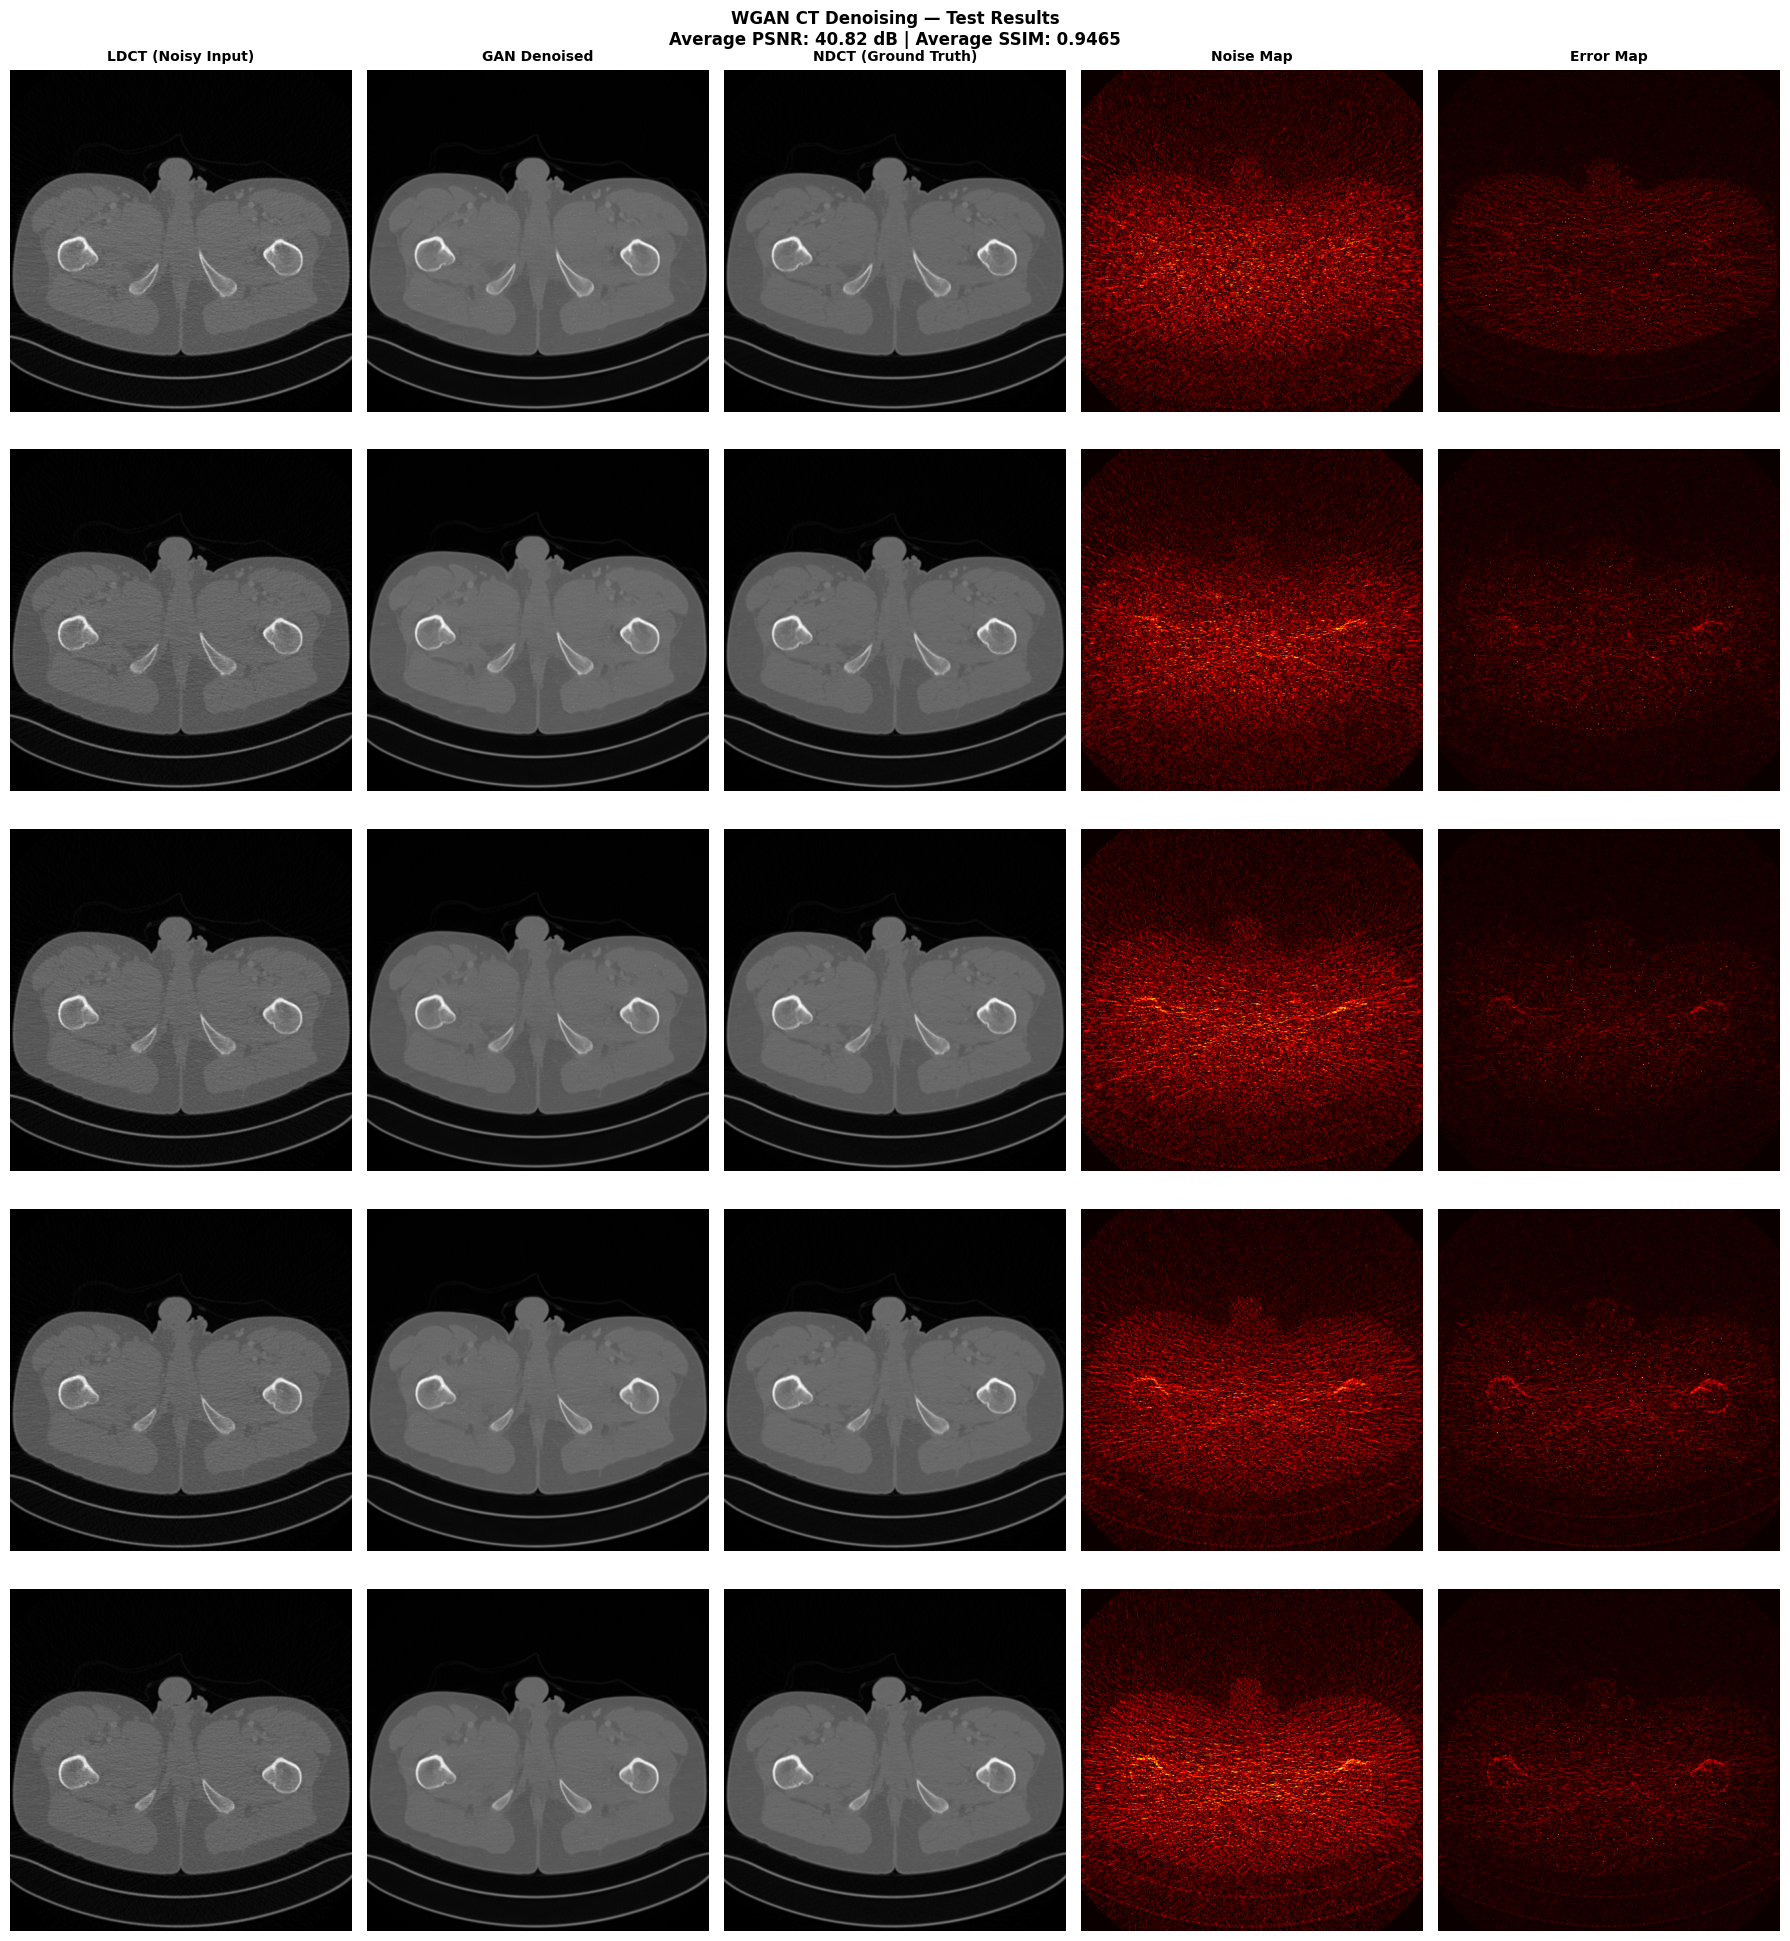

✓ Saved → /kaggle/working/gan_test_results.png


In [13]:
# ═══════════════════════════════════════════════════
# VISUALIZE RESULTS ON TEST DATA
# Shows 5 sample test images with metrics
# ═══════════════════════════════════════════════════

def visualize_test_results(generator, test_loader, n_samples=5):

    generator.eval()
    generator = generator.to(DEVICE)

    fig, axes = plt.subplots(n_samples, 5,
                              figsize=(18, 4 * n_samples))

    # Column titles
    titles = ["LDCT (Noisy Input)",
              "GAN Denoised",
              "NDCT (Ground Truth)",
              "Noise Map",
              "Error Map"]
    for c, t in enumerate(titles):
        axes[0, c].set_title(t, fontsize=10, fontweight='bold')
        sample_count = 0
    for ld_full, nd_full in test_loader:
        if sample_count >= n_samples:
            break

        with torch.no_grad():
            pred = generator(ld_full.to(DEVICE))

        ld_np   = np.clip(ld_full.squeeze().numpy(),        0, 1)
        nd_np   = np.clip(nd_full.squeeze().numpy(),        0, 1)
        pred_np = np.clip(pred.cpu().squeeze().numpy(),     0, 1)

        # Maps
        noise_map = np.abs(nd_np   - ld_np)
        error_map = np.abs(nd_np   - pred_np)

        # Metrics for this image
        p = psnr(nd_np, pred_np, data_range=1.0)
        s = ssim(nd_np, pred_np, data_range=1.0)
        # Plot
        axes[sample_count, 0].imshow(ld_np,    cmap='gray')
        axes[sample_count, 0].axis('off')

        axes[sample_count, 1].imshow(pred_np,  cmap='gray')
        axes[sample_count, 1].set_xlabel(
            f"PSNR: {p:.2f} dB | SSIM: {s:.4f}",
            fontsize=9
        )
        axes[sample_count, 1].axis('off')

        axes[sample_count, 2].imshow(nd_np,    cmap='gray')
        axes[sample_count, 2].axis('off')

        axes[sample_count, 3].imshow(noise_map, cmap='hot')
        axes[sample_count, 3].axis('off')

        axes[sample_count, 4].imshow(error_map, cmap='hot')
        axes[sample_count, 4].axis('off')

        sample_count += 1
        plt.suptitle(
        f"WGAN CT Denoising — Test Results\n"
        f"Average PSNR: {final_psnr:.2f} dB | "
        f"Average SSIM: {final_ssim:.4f}",
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()

    # Save figure
    save_path = "/kaggle/working/gan_test_results.png"
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved → {save_path}")


visualize_test_results(gan_generator, test_loader)

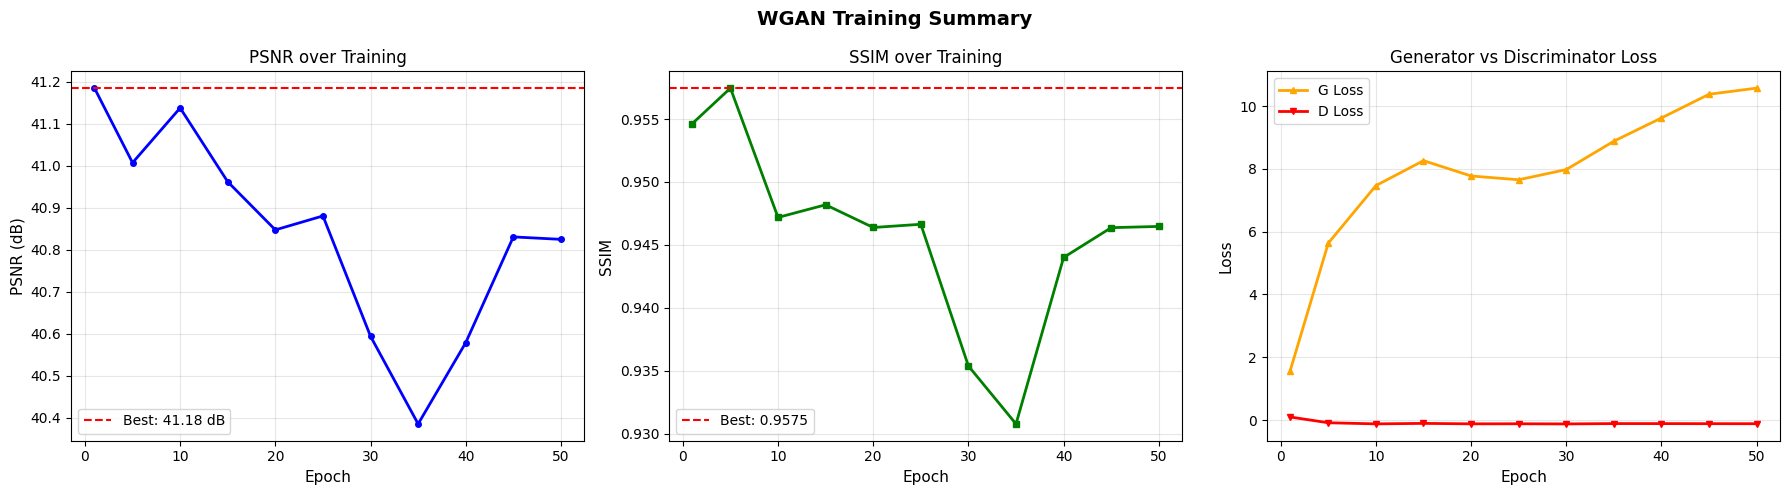

✓ Saved → /kaggle/working/gan_training_curves.png


In [14]:
# ═══════════════════════════════════════════════════
# PLOT TRAINING CURVES
# Shows how PSNR and SSIM improved over training
# ═══════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_list = gan_history["epoch"]

# Plot 1 — PSNR
axes[0].plot(epochs_list, gan_history["psnr"],
             color='blue', marker='o',
             markersize=4, linewidth=2)
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("PSNR (dB)", fontsize=11)
axes[0].set_title("PSNR over Training", fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=max(gan_history["psnr"]),
                color='red', linestyle='--',
                label=f'Best: {max(gan_history["psnr"]):.2f} dB')
axes[0].legend()
# Plot 2 — SSIM
axes[1].plot(epochs_list, gan_history["ssim"],
             color='green', marker='s',
             markersize=4, linewidth=2)
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("SSIM", fontsize=11)
axes[1].set_title("SSIM over Training", fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=max(gan_history["ssim"]),
                color='red', linestyle='--',
                label=f'Best: {max(gan_history["ssim"]):.4f}')
axes[1].legend()

# Plot 3 — Generator Loss
axes[2].plot(epochs_list, gan_history["loss_g"],
             color='orange', marker='^',
             markersize=4, linewidth=2,
             label='G Loss')
axes[2].plot(epochs_list, gan_history["loss_d"],
             color='red', marker='v',
             markersize=4, linewidth=2,
             label='D Loss')
axes[2].set_xlabel("Epoch", fontsize=11)
axes[2].set_ylabel("Loss", fontsize=11)
axes[2].set_title("Generator vs Discriminator Loss", fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle("WGAN Training Summary", fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = "/kaggle/working/gan_training_curves.png"
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")